This piece of code performs training of the NN against the PDF data. Prepared PDF data is required to run this code. The labels for data are taken from the names of each dataset, so better be prepared for labelling. In principle, this code can process both calculated PDF data, as well as experimental PDF data. The latter may require additinal processing which is performed by 'preparePDFexp.ipynb'. Calculated data may be prepared from a batch of xyz files by 'preparePDF.ipynb'

In [10]:
import numpy as np
np.random.seed(1337) 
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler, Normalizer
from keras.models import Sequential
from keras.layers import Dense, Conv1D, BatchNormalization, MaxPooling1D, LeakyReLU, Flatten, Dropout
from keras_self_attention import SeqSelfAttention
from keras.utils import custom_object_scope
from keras.callbacks import History, ModelCheckpoint, EarlyStopping
from keras import backend as K
from keras import metrics, regularizers
from keras.optimizers import Adam, Adagrad, Adadelta, RMSprop
from keras_tuner.tuners import Hyperband
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score
import keras.regularizers
import keras
import glob
import os
import itertools
import fnmatch

In [2]:
os.chdir('/Users/dimitrygrebenyuk/Yandex.Disk.localized/Working/PDF/Refinements/PDF-Cluster-Prediction/all_data')

In [3]:
files_calc = glob.glob('*.dat')
files_exp = glob.glob('*processed.gr')

Counts of clusters by their nuclearity: {'1': 0, '2': 13, '3': 12, '4': 50, '5': 10, '6': 19, '7': 8, '8': 5, '9': 6}
Sliced cluster catalogue: ['3_RAQFIA.dat', '4_EGEYOF.dat', '3_Gd3_new_cluster.dat', '4_dy4.dat', '4_MAGFOR.dat', '7_XOSZOW.dat', '6_Nd6O.dat', '4_ATODUK.dat', '4_ATODOE.dat', '2_GETPEB.dat', '3_AZUFUW.dat', '4_Nd4_tetr.dat', '2_DELHIM.dat', '7_OCOSIK.dat', '6_eu6-glaz.dat', '2_NAJKIU01.dat', '6_tb6piv.dat', '2_WABCIM.dat', '7_DOVBUN.dat', '4_IJAQOA.dat', '2_NERWOX.dat', '4_BOQXAH.dat', '2_la2(tfa)6(deta)2.dat', '6_Nd6.dat', '4_QEJWUZ.dat', '8_VIMNUC.dat', '6_SUTROQ.dat', '4_sm4_mono.dat', '5_HOPJAX01.dat', '4_Gd4_opt.dat', '7_BODGOS.dat', '3_Gd3(O)(tfa)7(Htfa)(H2O)n_opt.dat', '4_IMIGAN.dat', '4_Nd4.dat', '8_DAQJEM.dat', '4_tb4.dat', '9_BALLIL.dat', '5_LAVJAV.dat', '4_Eu4.dat', '2_Gd2(tfa)5(iPrOH)2(H2O)4_opt.dat', '4_ga18.dat', '8_UKANEA.dat', '6_CAKBAT.dat', '5_ARULIK.dat', '4_KIFDEI.dat', '6_XIRNIV.dat', '4_GIZVOA.dat', '6_wrong_cpd.dat', '3_HAYNIF.dat', '3_ADUSUO.dat'

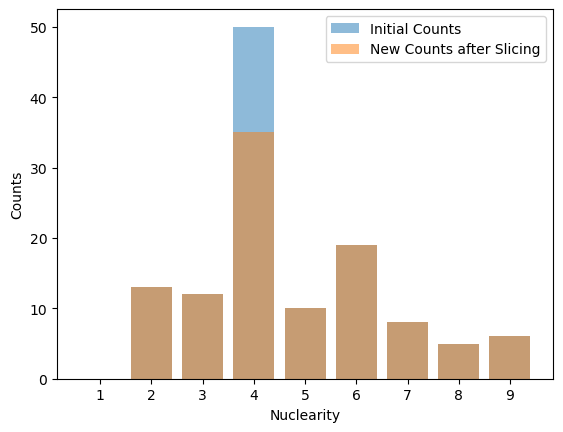

In [4]:
from collections import defaultdict
import matplotlib.pyplot as plt

def analyze_filenames(filenames):
    # Count how many filenames start with each digit from 1 to 9
    counts = defaultdict(int)
    for filename in filenames:
        if filename[0].isdigit() and filename[0] != '0':
            counts[filename[0]] += 1
            
    return counts

def create_output_array(filenames, selected_counts):
    # Create the output array based on the selected counts for each digit
    output_array = []
    current_counts = defaultdict(int)
    for filename in filenames:
        digit = filename[0]
        if digit in selected_counts and current_counts[digit] < selected_counts[digit]:
            output_array.append(filename)
            current_counts[digit] += 1
            
    return output_array

files_calc.extend(files_exp)
counts = analyze_filenames(files_calc)
sorted_counts = {str(digit): counts.get(str(digit), 0) for digit in range(1, 10)}
print("Counts of clusters by their nuclearity:", sorted_counts)

selected_counts = {
    '1': 100, # Specify how many filenames starting with '1' you want
    '2': 100, # Specify how many filenames starting with '2' you want
    '3': 100,  # Specify how many filenames starting with '3' you want
    '4': 35,  # Specify how many filenames starting with '3' you want
    '5': 100,  # Specify how many filenames starting with '3' you want
    '6': 100,  # Specify how many filenames starting with '3' you want
    '7': 100,  # Specify how many filenames starting with '3' you want
    '8': 100,  # Specify how many filenames starting with '3' you want
    '9': 100  # Specify how many filenames starting with '3' you want
}

files_calc_sliced = create_output_array(files_calc, selected_counts)
print("Sliced cluster catalogue:", files_calc_sliced)

counts = analyze_filenames(files_calc_sliced)
sorted_counts2 = {str(digit): counts.get(str(digit), 0) for digit in range(1, 10)}
print("Counts of clusters by their nuclearity:", sorted_counts2)

digits = list(sorted_counts.keys())
initial_values = list(sorted_counts.values())
new_values = list(sorted_counts2.values()) # Use sorted counts for the new values

total_elements_in_sliced = len(files_calc_sliced)
print("Total number of elements in the sliced cluster catalogue:", total_elements_in_sliced)

plt.bar(digits, initial_values, alpha=0.5, label='Initial Counts')
plt.bar(digits, new_values, alpha=0.5, label='New Counts after Slicing')
plt.xlabel('Nuclearity')
plt.ylabel('Counts')
plt.legend()
plt.show()


In [5]:
raw_data_points = []

with open('labels.txt', 'w') as labels:
    for f in files_calc_sliced:
        if 'processed' in f:
            # For files containing 'processed' in their names (second type)
            df = pd.read_csv(f, usecols=[1], skiprows=1, header=None, delim_whitespace=True, skipfooter=1, engine='python')
        else:
            # For files not containing 'processed' in their names (first type)
            df = pd.read_csv(f, usecols=[1], skiprows=201, header=None, delim_whitespace=True, skipfooter=0, engine='python')

        raw_data_points.append(df.values.ravel())
        labels.write(f[0])
        labels.write('\n')

raw_data_points = np.array(raw_data_points)

# Load the labels
labels = pd.read_csv("labels.txt", header=None)
labels = labels.values.ravel()  # convert the labels to a 1D array

4


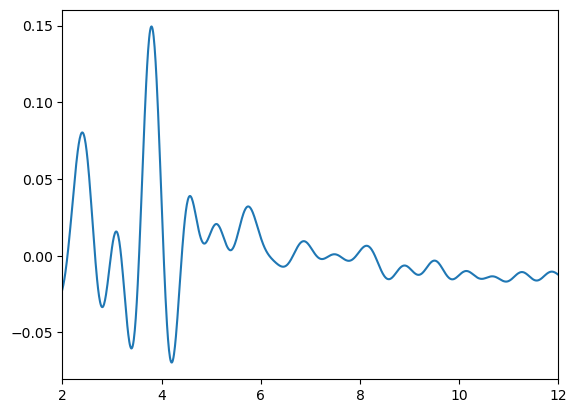

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
# Preprocessing
#scaler = MinMaxScaler()
#scaler = StandardScaler()
#scaler =MaxAbsScaler()
#data_points = scaler.fit_transform(data_points)
normalize = Normalizer()
data_points = normalize.fit_transform(raw_data_points)
fig, ax = plt.subplots()
ax.set_xlim(2,12)
ax.plot(np.arange(len(data_points[80,:]))/100+2, data_points[80,:])
print(labels[80])


In [11]:
def create_model():
    # Tuning of the model

    model = Sequential()
    # Add the convolutional layers
    model.add(Conv1D(filters=4, kernel_size=256, activation='relu', input_shape=(1000, 1))) # 8, 256
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2)) # 2
    model.add(Dropout(0.7)) # 0.5
    model.add(Conv1D(filters=64, kernel_size=128, activation='relu')) # 64, 32
    model.add(Conv1D(filters=64, kernel_size=32, activation='relu')) # 64, 32

    model.add(SeqSelfAttention(attention_width=32, attention_type=SeqSelfAttention.ATTENTION_TYPE_MUL)) # 32

    # Flatten the output of the convolutional layers
    model.add(Flatten())

    # Add the fully connected layers
    model.add(Dense(units=128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01))) # 128 l2 0.01
    model.add(Dropout(0.5))
    model.add(Dense(units=10, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.01))) # 10 l2 0.01

    # Compile the model
    #optimizer = RMSprop(learning_rate=0.0001) # 0.001
    optimizer = Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model


In [12]:
num_folds = 10
num_epochs = 200
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)
fold_num = 1  # to keep track of which fold you're on
all_fold_results = []  # list to store performance metrics for each fold

In [13]:
for train_index, val_index in kf.split(data_points):
    X_train, X_val = data_points[train_index], data_points[val_index]
    y_train, y_val = labels[train_index], labels[val_index]
    
    model = create_model()
    
    checkpoint_name = f"fold_{fold_num}_model.hdf5"
    checkpoint = ModelCheckpoint(checkpoint_name, monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)
    
    print(f'Training fold {fold_num}...')
    model.fit(X_train, y_train, epochs=num_epochs, validation_data=(X_val, y_val), callbacks=[checkpoint])
    
    # Load the best model saved by the checkpoint and evaluate
    with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
        load_model = keras.models.load_model(checkpoint_name)
        
    val_loss, val_acc = load_model.evaluate(X_val, y_val)
    print(f'Fold {fold_num} accuracy:', val_acc)
    
    all_fold_results.append(val_acc)
    
    fold_num += 1

# Print overall performance across all folds
print('All fold accuracies:', all_fold_results)
print('Mean accuracy:', np.mean(all_fold_results))
print('Standard deviation:', np.std(all_fold_results))

Training fold 1...
Epoch 1/200
3/4 [=====================>........] - ETA: 0s - loss: 4.9169 - accuracy: 0.3229
Epoch 1: val_accuracy improved from -inf to 0.23077, saving model to fold_1_model.hdf5
4/4 [==============================] - 1s 136ms/step - loss: 4.8905 - accuracy: 0.3545 - val_loss: 4.9419 - val_accuracy: 0.2308
Epoch 2/200
4/4 [==============================] - ETA: 0s - loss: 4.5944 - accuracy: 0.4273
Epoch 2: val_accuracy did not improve from 0.23077
4/4 [==============================] - 0s 84ms/step - loss: 4.5944 - accuracy: 0.4273 - val_loss: 4.8566 - val_accuracy: 0.2308
Epoch 3/200
3/4 [=====================>........] - ETA: 0s - loss: 4.3686 - accuracy: 0.4271
Epoch 3: val_accuracy did not improve from 0.23077
4/4 [==============================] - 0s 84ms/step - loss: 4.3765 - accuracy: 0.4273 - val_loss: 4.7724 - val_accuracy: 0.2308
Epoch 4/200
3/4 [=====================>........] - ETA: 0s - loss: 4.3160 - accuracy: 0.4062
Epoch 4: val_accuracy did not impro

In [16]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(data_points, labels, test_size=0.2, random_state=42)

# Tuning of the model

model = Sequential()
# Add the convolutional layers
model.add(Conv1D(filters=32, kernel_size=128, activation='relu', input_shape=(1000, 1))) # 32, 128
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2)) # 2
model.add(Dropout(0.5)) # 0.5
model.add(Conv1D(filters=64, kernel_size=32, activation='relu')) # 64, 32

model.add(SeqSelfAttention(attention_width=32, attention_type=SeqSelfAttention.ATTENTION_TYPE_MUL)) # 32

# Flatten the output of the convolutional layers
model.add(Flatten())

# Add the fully connected layers
model.add(Dense(units=128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.0001))) # 128 l2 0.01
model.add(Dropout(0.5))
model.add(Dense(units=10, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.0001))) # 10 l2 0.01

# Compile the model
#optimizer = RMSprop(learning_rate=0.0001) # 0.001
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_35 (Conv1D)          (None, 873, 32)           4128      
                                                                 
 batch_normalization_12 (Bat  (None, 873, 32)          128       
 chNormalization)                                                
                                                                 
 max_pooling1d_12 (MaxPoolin  (None, 436, 32)          0         
 g1D)                                                            
                                                                 
 dropout_24 (Dropout)        (None, 436, 32)           0         
                                                                 
 conv1d_36 (Conv1D)          (None, 405, 64)           65600     
                                                                 
 seq_self_attention_12 (SeqS  (None, 405, 64)        

In [17]:
# Train the model
num_epochs = 200

checkpoint = ModelCheckpoint("all_0-12.hdf5", monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)

seqModel = model.fit(X_train, y_train, epochs=num_epochs, validation_data=(X_test, y_test), callbacks=[checkpoint])
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test accuracy:', test_acc)

Epoch 1/200
3/4 [=====================>........] - ETA: 0s - loss: 2.1584 - accuracy: 0.2812
Epoch 1: val_accuracy improved from -inf to 0.32000, saving model to all_0-12.hdf5
4/4 [==============================] - 1s 144ms/step - loss: 2.1554 - accuracy: 0.2857 - val_loss: 2.3116 - val_accuracy: 0.3200
Epoch 2/200
3/4 [=====================>........] - ETA: 0s - loss: 1.9329 - accuracy: 0.4271
Epoch 2: val_accuracy did not improve from 0.32000
4/4 [==============================] - 0s 88ms/step - loss: 1.9236 - accuracy: 0.4286 - val_loss: 2.3027 - val_accuracy: 0.3200
Epoch 3/200
3/4 [=====================>........] - ETA: 0s - loss: 1.7613 - accuracy: 0.4375
Epoch 3: val_accuracy did not improve from 0.32000
4/4 [==============================] - 0s 87ms/step - loss: 1.7552 - accuracy: 0.4388 - val_loss: 2.2970 - val_accuracy: 0.3200
Epoch 4/200
3/4 [=====================>........] - ETA: 0s - loss: 1.7242 - accuracy: 0.4583
Epoch 4: val_accuracy did not improve from 0.32000
4/4 [==

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


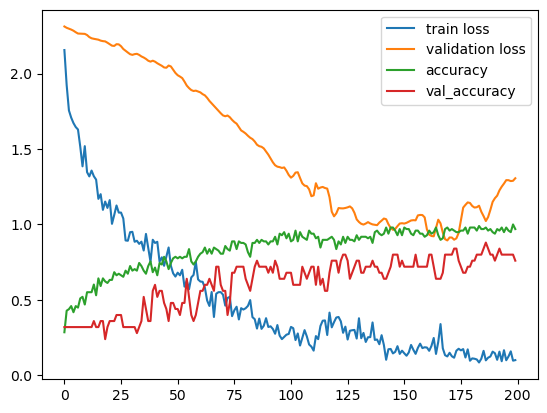

In [18]:
print(seqModel.history.keys())
xc         = range(num_epochs)

plt.plot(xc, seqModel.history['loss'], label='train loss')
plt.plot(xc, seqModel.history['val_loss'], label='validation loss')
plt.plot(xc, seqModel.history['accuracy'], label='accuracy')
plt.plot(xc, seqModel.history['val_accuracy'], label='val_accuracy')
plt.legend()

In [19]:
with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    load_model = keras.models.load_model('all_0-12.hdf5')

In [22]:
load_model.evaluate(X_test, y_test)
y_pred_prob = load_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
confusion = confusion_matrix(y_test, y_pred)
recall = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)
precision = precision_score(y_test, y_pred, average=None)
print('Confusion matrix', confusion)
print('Recall score:', recall)
print('F1 score:', f1)
print('Precision score:', precision)

1/1 [==============================] - 0s 36ms/step
Confusion matrix [[1 0 0 0 0 0]
 [0 5 0 0 0 0]
 [1 1 6 0 0 0]
 [0 0 1 2 0 0]
 [0 0 0 0 6 0]
 [0 0 0 0 0 2]]
Recall score: [1.         1.         0.75       0.66666667 1.         1.        ]
F1 score: [0.66666667 0.90909091 0.8        0.8        1.         1.        ]
Precision score: [0.5        0.83333333 0.85714286 1.         1.         1.        ]


Confusion matrix, without normalization
[[1 0 0 0 0 0]
 [0 5 0 0 0 0]
 [1 1 6 0 0 0]
 [0 0 1 2 0 0]
 [0 0 0 0 6 0]
 [0 0 0 0 0 2]]


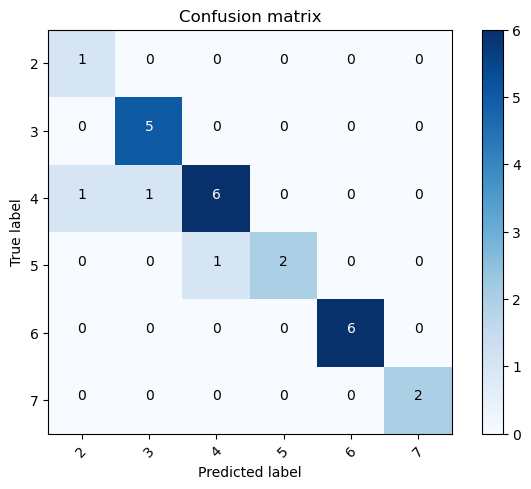

In [23]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Plot the confusion matrix
plot_confusion_matrix(confusion, classes = np.unique(y_test), title='Confusion matrix', normalize=False)
plt.show()

Let's combine the 10-fold which looks sort of okay with hyperparameter tuning to acheive better results

In [15]:
def build_model(hp):
    model = Sequential()
    model.add(Conv1D(filters=hp.Choice('filters1', [4, 8, 16, 32]),
                     kernel_size=hp.Choice('kernel_size1', [32, 64, 128, 256]),
                     activation='relu', input_shape=(1000, 1)))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(hp.Float('dropout1', 0.1, 0.9, step=0.1)))
    model.add(Conv1D(filters=hp.Choice('filters2', [8, 16, 32, 64, 128]),
                     kernel_size=hp.Choice('kernel_size2', [16, 32, 64, 128]),
                     activation='relu'))
    model.add(Conv1D(filters=hp.Choice('filters2', [8, 16, 32, 64, 128]),
                     kernel_size=hp.Choice('kernel_size2', [16, 32, 64, 128]),
                     activation='relu'))                 
    model.add(Dropout(hp.Float('dropout2', 0.1, 0.9, step=0.1)))
    model.add(SeqSelfAttention(attention_width=16, attention_type=SeqSelfAttention.ATTENTION_TYPE_MUL))
    model.add(Flatten())
    model.add(Dense(units=hp.Choice('dense_units', [32, 64, 128, 256]), activation=hp.Choice('activation',['relu', 'softmax']), kernel_regularizer=keras.regularizers.l2(0.01)))
    model.add(Dropout(hp.Float('dropout3', 0.1, 0.9, step=0.1)))
    model.add(Dense(units=10, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.01)))
    optimizer = Adam(learning_rate=hp.Float('learning_rate', 1e-4, 1e-1, sampling='log'))
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [11]:
# K-Fold cross-validation
num_folds = 10
kf = KFold(n_splits=num_folds)

# Track the best hyperparameters and scores
best_hps = []
best_scores = []

for train_index, val_index in kf.split(data_points):
    train_data, val_data = data_points[train_index], data_points[val_index]
    train_targets, val_targets = labels[train_index], labels[val_index]

    tuner = Hyperband(
        build_model,
        objective='val_accuracy',
        max_epochs=200,
        factor=3,
        project_name='hyperband_kfold'
    )

    # Search for the best hyperparameters for this fold
    tuner.search(train_data, train_targets, epochs=200, validation_data=(val_data, val_targets), callbacks=[EarlyStopping(monitor='val_loss', patience=3)])

    # Get the optimal hyperparameters
    best_hps.append(tuner.get_best_hyperparameters(num_trials=1)[0])
    best_scores.append(tuner.results_summary())

Trial 254 Complete [00h 00m 03s]
val_accuracy: 0.4545454680919647

Best val_accuracy So Far: 0.8181818127632141
Total elapsed time: 00h 13m 50s
INFO:tensorflow:Oracle triggered exit
Results summary
Results in ./hyperband_kfold
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 0147 summary
Hyperparameters:
filters1: 4
kernel_size1: 256
dropout1: 0.7000000000000001
filters2: 8
kernel_size2: 16
dropout2: 0.2
dense_units: 256
activation: relu
dropout3: 0.1
learning_rate: 0.0005428659940212535
tuner/epochs: 150
tuner/initial_epoch: 50
tuner/bracket: 4
tuner/round: 4
tuner/trial_id: 0144
Score: 0.8181818127632141

Trial 0235 summary
Hyperparameters:
filters1: 4
kernel_size1: 64
dropout1: 0.7000000000000001
filters2: 16
kernel_size2: 128
dropout2: 0.5
dense_units: 128
activation: relu
dropout3: 0.4
learning_rate: 0.0002160179561607897
tuner/epochs: 150
tuner/initial_epoch: 50
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0231
Score: 0.8181818127632141

Trial 0142

In [14]:
print(best_hps)
print(best_scores)


[<keras_tuner.engine.hyperparameters.hyperparameters.HyperParameters object at 0x148592c10>, <keras_tuner.engine.hyperparameters.hyperparameters.HyperParameters object at 0x148e85f70>, <keras_tuner.engine.hyperparameters.hyperparameters.HyperParameters object at 0x1491bfa60>, <keras_tuner.engine.hyperparameters.hyperparameters.HyperParameters object at 0x1494b45b0>, <keras_tuner.engine.hyperparameters.hyperparameters.HyperParameters object at 0x149821c70>, <keras_tuner.engine.hyperparameters.hyperparameters.HyperParameters object at 0x149c14ac0>, <keras_tuner.engine.hyperparameters.hyperparameters.HyperParameters object at 0x149eb2cd0>, <keras_tuner.engine.hyperparameters.hyperparameters.HyperParameters object at 0x149f74790>, <keras_tuner.engine.hyperparameters.hyperparameters.HyperParameters object at 0x14a2bc850>, <keras_tuner.engine.hyperparameters.hyperparameters.HyperParameters object at 0x14a6c4400>]
[None, None, None, None, None, None, None, None, None, None]


In [ ]:

# Rebuild the model with the best hyperparameters
best_model = Sequential()
best_model.add(Conv1D(filters=16, kernel_size=32, activation='relu', input_shape=(1000, 1)))
best_model.add(BatchNormalization())
best_model.add(MaxPooling1D(pool_size=2)) # 2
best_model.add(Dropout(0.1))
best_model.add(Conv1D(filters=32, kernel_size=128, activation='relu'))
best_model.add(Dropout(0.9))
best_model.add(SeqSelfAttention(attention_width=16, attention_type=SeqSelfAttention.ATTENTION_TYPE_MUL))
best_model.add(Flatten())
best_model.add(Dense(units=128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01))) # 128 0.01
best_model.add(Dropout(0.5))
best_model.add(Dense(units=10, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.01))) # 10 0.01
optimizer = Adam(learning_rate=0.0003)
best_model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model with all training data
best_model.fit(data_points, labels, epochs=200, callbacks=[EarlyStopping(monitor='val_loss', patience=3)])

# Save the model
best_model.save('path/to/your/location/best_model.h5')
